# Forecasting Baselines
This notebook evaluates our simple seasonal baseline models before generating more complex ML models. We can visualize the performance here.

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import sys
import os
import importlib

# Add src to module path for importing custom code
sys.path.append(os.path.abspath('../../src'))
import forecasting.lstm_model
importlib.reload(forecasting.lstm_model)
from forecasting.baseline_models import (
    DailyNaiveForecaster, 
    WeeklyNaiveForecaster, 
    CombinedSeasonalForecaster, 
    evaluate_baselines
)
from forecasting.lstm_model import LSTMForecaster


In [28]:
# Load data
# Note: As of the new integration interface, models need the entire raw data format 
# to anchor prediction bounds to specific solve_times over a 35h horizon.
from forecasting.data_cleaning import load_and_clean_data
from forecasting.fill_missing_data import fill_missing_linear

# Load full raw series
df_full = load_and_clean_data('../../data/forecasting/raw/raw_data_measured_demand.csv')
df_full = fill_missing_linear(df_full)

# Pick an arbitrary test split for evaluation / testing.
# We set this back a few days from the end of our dataset to ensure we have
# a full 35 hours of "actual" future data to evaluate our metrics against!
solve_time = pd.Timestamp("2026-02-26T00:00:00Z")
horizon = 35

# history is everything up to the solve_time
df_history = df_full[df_full.index < solve_time]
# actuals is the exact 35 hour window we want to predict
y_test = df_full[(df_full.index >= solve_time) & (df_full.index < solve_time + pd.Timedelta(hours=horizon))]['heat_demand_W']

df_history.tail(3)

Resampling to hourly frequency to ensure consistent timestamps...


,heat_demand_W
timestamp,
2026-02-25 21:00:00+00:00,5.693508e+06
2026-02-25 22:00:00+00:00,5.228496e+06
2026-02-25 23:00:00+00:00,5.091608e+06


In [ ]:
# Dictionary to define all models to benchmark
models = {
    'Daily Naive': DailyNaiveForecaster(),
    'Weekly Naive': WeeklyNaiveForecaster(),
    'Combined Naive': CombinedSeasonalForecaster(),
    'LSTM': LSTMForecaster(
        lookback=168, 
        horizon=35, 
        epochs=30,           
        batch_size=64,
        learning_rate=1e-3
    )
}

predictions = {}

# Generate predictions conforming to the new pipeline API
for name, model in models.items():
    # Note: ML models would typically have a model.fit(df_history) call here first
    if name == 'LSTM':
        print(f"Training {name}... this might take a minute.")
        
        y_train = df_history['heat_demand_W']
        X_train = df_history.drop(columns=['heat_demand_W'])
        
        print(f"[{name}] Training on data up to {solve_time}...")
        model.fit(X=X_train, y=y_train)
    
    # Models return predictions in Megawatts ('demand_mw_th'), we convert back to Watts 
    # to evaluate cleanly against 'heat_demand_W' backwards compatibility in this notebook
    pred_mw = model.predict(history=df_history, solve_time=solve_time, horizon=horizon)
    pred_w = pred_mw * 1e6
    predictions[name] = pred_w
    
    print(f"[{name}] Metrics:", evaluate_baselines(y_test, pred_w))

[Daily Naive] Metrics: {'mae': np.float64(1119484.2106993534), 'rmse': np.float64(1284650.177600579), 'mape_pct': np.float64(20.95376230039346), 'r2': np.float64(-0.040556006921212084)}
[Weekly Naive] Metrics: {'mae': np.float64(5681495.541406466), 'rmse': np.float64(5844687.0168045135), 'mape_pct': np.float64(109.4942925033594), 'r2': np.float64(-20.538637020833548)}
[Combined Naive] Metrics: {'mae': np.float64(3365577.640915345), 'rmse': np.float64(3474492.605185001), 'mape_pct': np.float64(64.77031817429673), 'r2': np.float64(-6.611644237974032)}
Training LSTM... this might take a minute.
[LSTM] Training on data up to 2026-02-26 00:00:00+00:00...
Epoch 1/3
243/243 ━━━━━━━━━━━━━━━━━━━━ 141s 535ms/step - loss: 0.4135 - mae: 0.7032 - val_loss: 0.6967 - val_mae: 1.0992 - learning_rate: 0.0010
Epoch 2/3
243/243 ━━━━━━━━━━━━━━━━━━━━ 108s 444ms/step - loss: 0.3486 - mae: 0.6236 - val_loss: 0.6581 - val_mae: 1.0541 - learning_rate: 0.0010
Epoch 3/3
243/243 ━━━━━━━━━━━━━━━━━━━━ 106s 435ms/st

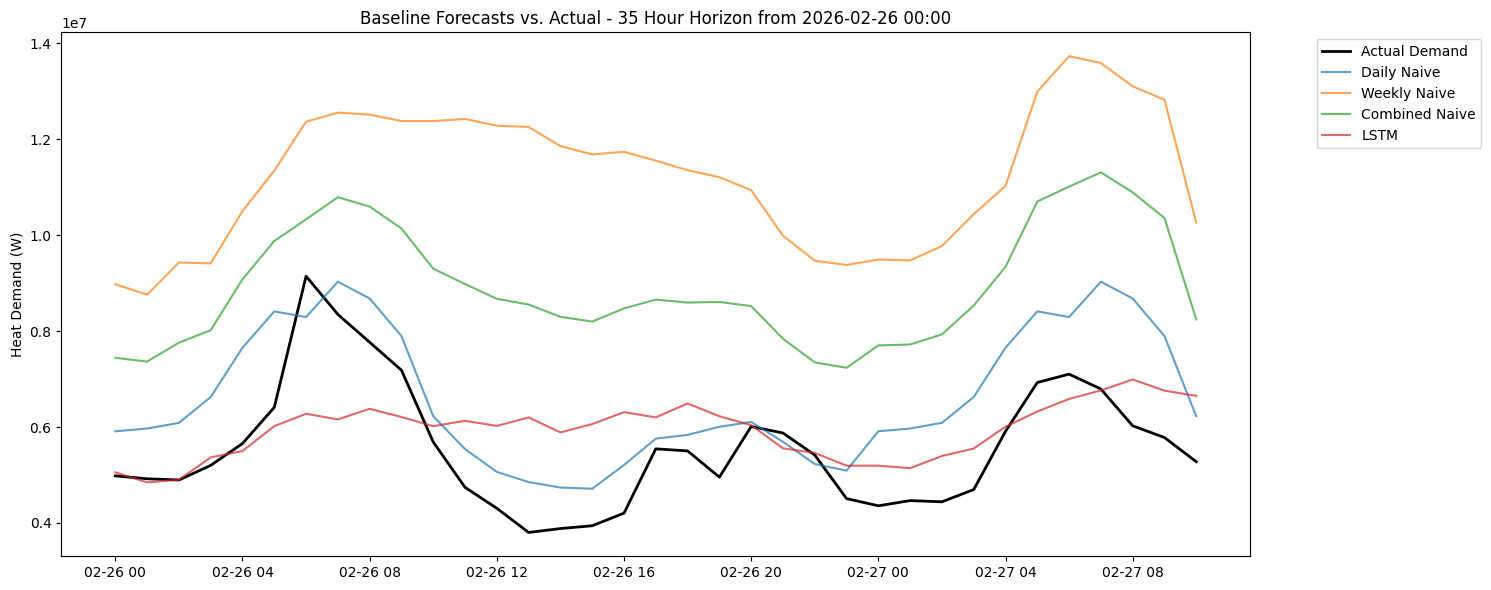

In [30]:
# Visualizing the 35 hour prediction horizon side-by-side
# Since our test horizon is exactly 35 hours starting at solve_time
start = solve_time
end = solve_time + pd.Timedelta(hours=horizon)

plt.figure(figsize=(15, 6))
plt.plot(y_test.index, y_test.values, label='Actual Demand', color='black', linewidth=2)

for name, pred in predictions.items():
    plt.plot(pred.index, pred.values, label=name, alpha=0.7)

plt.title(f'Baseline Forecasts vs. Actual - 35 Hour Horizon from {start.strftime("%Y-%m-%d %H:%M")}')
plt.ylabel('Heat Demand (W)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## Detailed Error Analysis

Let's compare the performance using our updated metrics:
- **MAE (Mean Absolute Error):** The average absolute difference between the forecast and actual demand. It tells us the expected error in Watts.
- **RMSE (Root Mean Squared Error):** Also in Watts, but squares the errors before averaging, effectively penalizing larger errors more heavily. Helpful for checking if the model misses big spikes.
- **MAPE (Mean Absolute Percentage Error):** The average relative percentage error. Useful for understanding the scale of the errors independent of the actual unit volume.
- **R² (Coefficient of Determination):** Measures the proportion of variance explained by the model. 1.0 represents a perfect forecast, 0.0 represents a model no better than just predicting the historical mean, and negative values indicate performance worse than the mean.

,mae,rmse,mape_pct,r2
Daily Naive,1119484.21,1284650.18,20.95,-0.04
Weekly Naive,5681495.54,5844687.02,109.49,-20.54
Combined Naive,3365577.64,3474492.61,64.77,-6.61
LSTM,921196.55,1202822.33,17.90,0.09


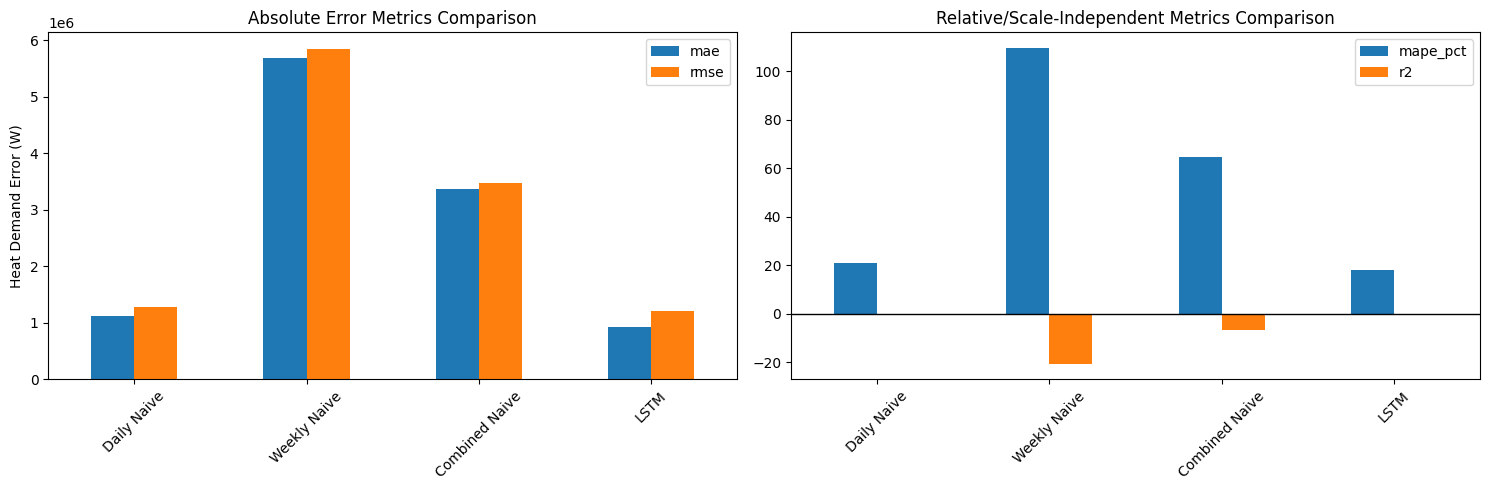

In [31]:
import numpy as np

# Calculate comprehensive metrics dynamically
metrics_dict = {
    name: evaluate_baselines(y_test, pred)
    for name, pred in predictions.items()
}
metrics_df = pd.DataFrame(metrics_dict).T

# Formatting the output slightly better
display(metrics_df.round(2))

# Plot Metrics Comparison side-by-side
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# MAE & RMSE
metrics_df[['mae', 'rmse']].plot(kind='bar', ax=axes[0])
axes[0].set_title('Absolute Error Metrics Comparison')
axes[0].set_ylabel('Heat Demand Error (W)')
axes[0].tick_params(axis='x', rotation=45)

# MAPE & R2
metrics_df[['mape_pct', 'r2']].plot(kind='bar', ax=axes[1])
axes[1].set_title('Relative/Scale-Independent Metrics Comparison')
axes[1].axhline(0, color='black', linewidth=1)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

Metrics for the first forecasted hour (1-step ahead):


c:\Users\ramii\OneDrive\Documents\GitHub\datascience\src\forecasting\baseline_models.py:55: RuntimeWarning: divide by zero encountered in scalar divide
  r2 = 1 - (np.sum((y_t - y_p)**2) / np.sum((y_t - np.mean(y_t))**2))


,mae,rmse,mape_pct,r2
Daily Naive,929675.62,929675.62,18.66,-inf
Weekly Naive,3995001.95,3995001.95,80.19,-inf
Combined Naive,2462338.78,2462338.78,49.43,-inf
LSTM,72966.68,72966.68,1.46,-inf


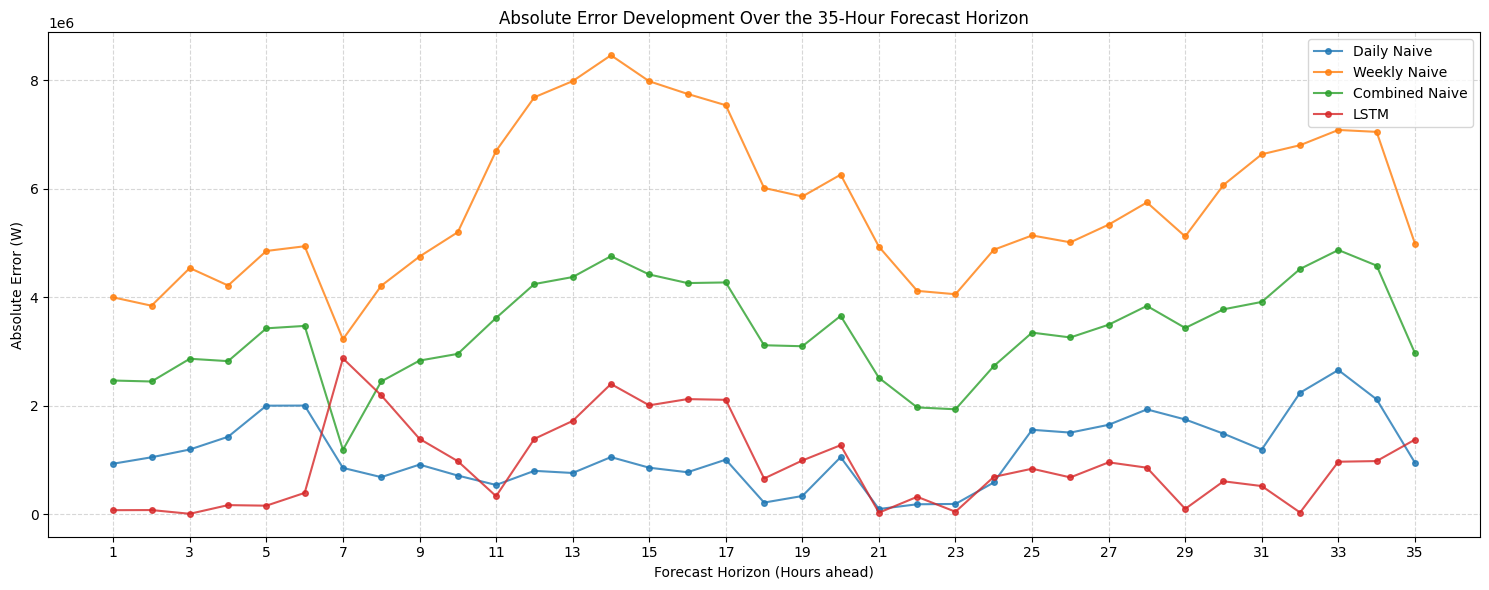

In [32]:
# 1-Hour Ahead Metrics
print("Metrics for the first forecasted hour (1-step ahead):")
metrics_1h_dict = {}
for name, pred in predictions.items():
    # Pass only the very first hour into the evaluation function
    metrics_1h_dict[name] = evaluate_baselines(y_test.iloc[[0]], pred.iloc[[0]])

display(pd.DataFrame(metrics_1h_dict).T.round(2))

# Error Development over the 35-hour Horizon
plt.figure(figsize=(15, 6))

for name, pred in predictions.items():
    # Calculate absolute error for each step in the 35-hour horizon
    abs_error = np.abs(y_test.values - pred.values)
    # X-axis represents the forecast hour from 1 to 35
    horizon_hours = np.arange(1, len(abs_error) + 1)
    
    plt.plot(horizon_hours, abs_error, marker='o', markersize=4, label=name, alpha=0.8)

plt.title('Absolute Error Development Over the 35-Hour Forecast Horizon')
plt.xlabel('Forecast Horizon (Hours ahead)')
plt.ylabel('Absolute Error (W)')
plt.xticks(np.arange(1, horizon + 1, 2))
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

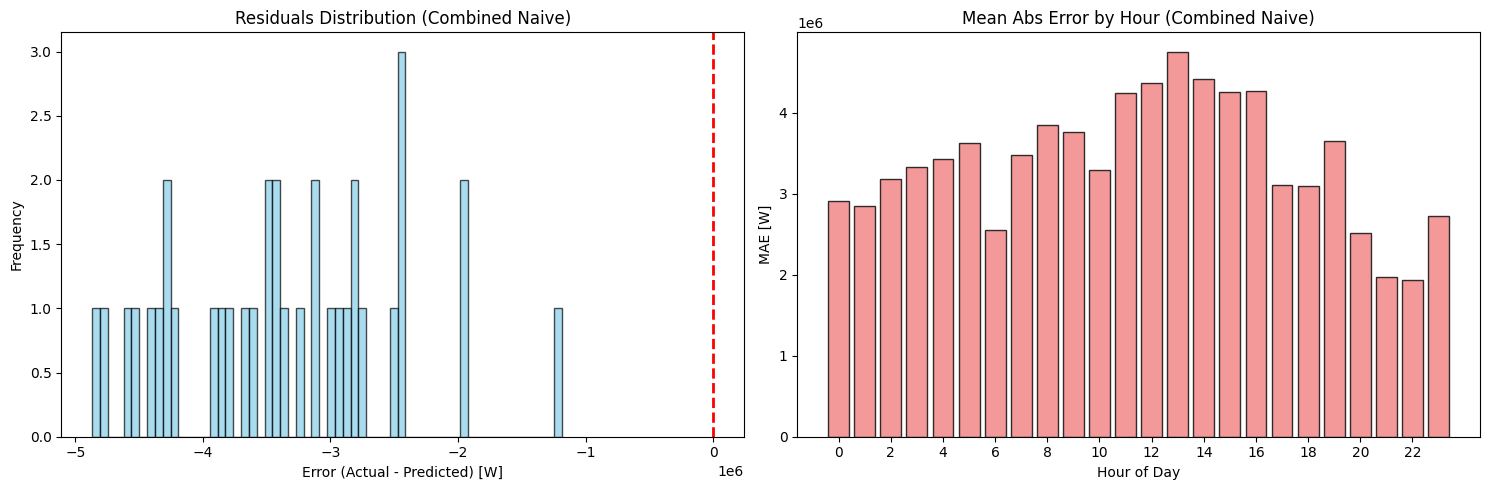

In [33]:
# Residuals Analysis for a specific model 
# (You can change 'best_model_name' to inspect any model in the dictionary)
best_model_name = 'Combined Naive' 

assert best_model_name in predictions, f"Model {best_model_name} not found in predictions dictionary"
residuals = y_test - predictions[best_model_name]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 1. Histogram to evaluate residual normal distribution
axes[0].hist(residuals.dropna(), bins=60, color='skyblue', edgecolor='black', alpha=0.7)
axes[0].axvline(0, color='red', linestyle='dashed', linewidth=2)
axes[0].set_title(f'Residuals Distribution ({best_model_name})')
axes[0].set_xlabel('Error (Actual - Predicted) [W]')
axes[0].set_ylabel('Frequency')

# 2. Mean Absolute Error by Hour of Day
err_df = pd.DataFrame({'residual': residuals, 'hour': residuals.index.hour})
err_by_hour = err_df.groupby('hour')['residual'].apply(lambda x: np.mean(np.abs(x)))

axes[1].bar(err_by_hour.index, err_by_hour.values, color='lightcoral', alpha=0.8, edgecolor='black')
axes[1].set_title(f'Mean Abs Error by Hour ({best_model_name})')
axes[1].set_xlabel('Hour of Day')
axes[1].set_ylabel('MAE [W]')
axes[1].set_xticks(range(0, 24, 2))

plt.tight_layout()
plt.show()